# Linear probe vs zero-shot: held-out accuracy

This notebook measures the phenomenon head two ways -- zero-shot CLIP prompting and the trained linear probe -- and reports the honest headline number plus the per-class breakdown, confusion matrix, and cross-validation behind it.

**Read this before the numbers below.**

- **Held-out `data/test` covers only CLEAR, CLOUDY, RAIN.** The Multi-class Weather Dataset (cloudy, rain, shine, sunrise) is the only source with an independent held-out half; the Weather Image Recognition dataset supplies FOG, SNOW, and STORM entirely, with no second independent sample to hold out from it. So the zero-shot-vs-probe *held-out* accuracy in section 2 only covers 3 of the 6 groups -- section 4 adds 5-fold cross-validation over the training pool to get an honest, differently-sourced number for all six.
- **The Multi-class Weather Dataset ships duplicate photographs under different filenames** -- some byte-identical, some a recompressed near-copy. A file-level split that only sorts and alternates places both copies of such a pair on opposite sides of the split with near-certainty, silently leaking training images into the "held-out" set. `training/train_probe.py::split_dataset` deduplicates each class by content hash (exact md5, then a perceptual dHash for recompressed near-copies) before alternating; 154 of 1,125 source images (13.7%) were duplicates and are excluded from both sides. See the fix report for the per-class breakdown.
- **The confusion matrix below is a full 6x6.** FOG/SNOW/STORM rows are empty because `data/test` has no ground truth for them -- not because the probe never predicts into those rows. Section 2 reports how often a genuinely CLEAR/CLOUDY/RAIN photo gets scored into FOG or SNOW, which is the number that matters for the backend's phenomenon-matching rule.

In [1]:
# Make repo-root imports (app.*, training.*) and repo-root-relative paths
# (data/test, data/golden) work regardless of the kernel's starting cwd.
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "training" else Path.cwd()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
print("cwd:", Path.cwd())

cwd: /workspace/skydex-vision


### 1. Embed the held-out test set

In [2]:
from pathlib import Path
import numpy as np
from app.model import VisionModel
from training.train_probe import embed_folder

model = VisionModel()
features, labels = embed_folder(model, Path("data/test"))
print(len(labels), set(labels))

/workspace/skydex-vision/.venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


/workspace/skydex-vision/.venv/lib/python3.11/site-packages/open_clip/factory.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, 

cloudy -> CLOUDY: 130 images


rain -> RAIN: 95 images


shine -> CLEAR: 109 images


sunrise -> CLEAR: 151 images


485 {'CLOUDY', 'RAIN', 'CLEAR'}


### 2. Accuracy: zero-shot vs probe, per-class report for the probe

Same held-out images, same preprocessing, both arms -- the only difference between `zero_shot` and `probed` is which of the two phenomenon heads scored the embedding.

In [3]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from app.probe import load_probe
from app.prompts import GROUP_SIZES
from app.scoring import group_scores
import torch

probe = load_probe(Path("data/probe.npz"))

zero_shot, probed = [], []
for vector in features:
    sims = (torch.tensor(vector) @ model._phenomenon_features.T).tolist()
    zero_shot.append(max(group_scores(sims, GROUP_SIZES).items(), key=lambda kv: kv[1])[0])
    probed.append(max(probe.apply(vector).items(), key=lambda kv: kv[1])[0])

print("zero-shot:", accuracy_score(labels, zero_shot))
print("probe:    ", accuracy_score(labels, probed))
print(classification_report(labels, probed))

# The number that matters for the product, not just for the model: the
# backend's contradiction matrix admits only FOG for FOG and only SNOW
# for SNOW, so a held-out CLEAR/CLOUDY/RAIN photo scored into FOG or SNOW
# is exactly a legitimate capture the backend would then block.
fog_or_snow = sum(1 for p in probed if p in ("FOG", "SNOW"))
print(
    f"\nheld-out honest CLEAR/CLOUDY/RAIN photos scored by the probe into "
    f"FOG or SNOW: {fog_or_snow}/{len(probed)} ({fog_or_snow / len(probed):.1%})\n"
    "-- this is the rate at which the probe would cause the backend to reject "
    "a legitimate capture as a phenomenon mismatch."
)

zero-shot: 0.843298969072165
probe:     0.9195876288659793
              precision    recall  f1-score   support

       CLEAR       0.98      0.94      0.96       260
      CLOUDY       0.94      0.91      0.92       130
         FOG       0.00      0.00      0.00         0
        RAIN       0.98      0.88      0.93        95
        SNOW       0.00      0.00      0.00         0
       STORM       0.00      0.00      0.00         0

    accuracy                           0.92       485
   macro avg       0.48      0.46      0.47       485
weighted avg       0.97      0.92      0.94       485


held-out honest CLEAR/CLOUDY/RAIN photos scored by the probe into FOG or SNOW: 20/485 (4.1%)
-- this is the rate at which the probe would cause the backend to reject a legitimate capture as a phenomenon mismatch.


/workspace/skydex-vision/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/workspace/skydex-vision/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/workspace/skydex-vision/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


For reference, the zero-shot classification report on the same held-out set:

In [4]:
print(classification_report(labels, zero_shot))

              precision    recall  f1-score   support

       CLEAR       0.99      0.90      0.94       260
      CLOUDY       0.94      0.72      0.81       130
         FOG       0.00      0.00      0.00         0
        RAIN       0.92      0.85      0.89        95
        SNOW       0.00      0.00      0.00         0
       STORM       0.00      0.00      0.00         0

    accuracy                           0.84       485
   macro avg       0.47      0.41      0.44       485
weighted avg       0.96      0.84      0.90       485



/workspace/skydex-vision/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/workspace/skydex-vision/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/workspace/skydex-vision/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 3. Confusion matrix (probe, held-out set)

Full 6x6 over `GROUP_ORDER`, not restricted to the labels present in `data/test`. FOG/SNOW/STORM rows are empty (no ground truth for them here) but their columns are not -- that is where the FOG/SNOW misclassification count above shows up visually.

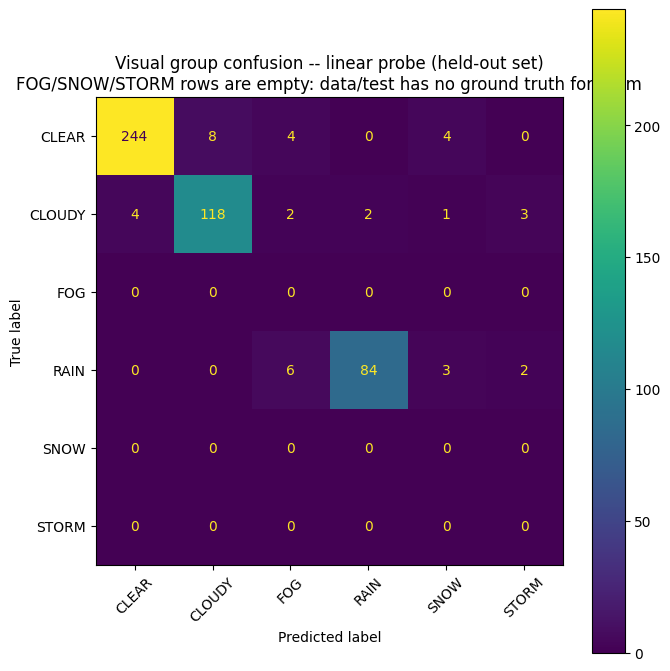

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from app.prompts import GROUP_ORDER

fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay.from_predictions(labels, probed, labels=GROUP_ORDER, ax=ax, xticks_rotation=45)
ax.set_title(
    "Visual group confusion -- linear probe (held-out set)\n"
    "FOG/SNOW/STORM rows are empty: data/test has no ground truth for them"
)
plt.tight_layout()
plt.savefig("training/confusion_matrix.png", dpi=120)
plt.show()

### 4. Cross-validated accuracy across all six groups

`data/test` cannot answer the FOG/SNOW/STORM question honestly -- there is no independent sample of those groups in either Kaggle source. 5-fold stratified cross-validation over the training pool instead: each fold's predictions come from a model that never saw those particular rows during that fold's fit, so the out-of-fold accuracy is genuinely held-out *within the training pool*, at zero cost to the data the shipped probe ultimately trains on (it refits on all of it afterwards). This answers a different question than section 2 -- it is not a substitute for an independent test set, but it is the only honest per-class signal available for FOG/SNOW/STORM.

Reuses the embeddings `training/train_probe.py` already cached to `data/train_embeddings.npz` -- no re-embedding, so this costs only the five logistic regression fits (seconds).

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict

cache = np.load("data/train_embeddings.npz", allow_pickle=False)
train_features, train_labels = cache["features"], [str(l) for l in cache["labels"]]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
oof_predictions = cross_val_predict(
    LogisticRegression(max_iter=2000, C=1.0),
    train_features,
    train_labels,
    cv=cv,
)

print(f"{len(train_labels)} training-pool embeddings, 5-fold stratified CV, out-of-fold predictions")
print(f"out-of-fold accuracy: {accuracy_score(train_labels, oof_predictions):.4f}")
print(classification_report(train_labels, oof_predictions))

6656 training-pool embeddings, 5-fold stratified CV, out-of-fold predictions
out-of-fold accuracy: 0.9606
              precision    recall  f1-score   support

       CLEAR       0.98      0.94      0.96       261
      CLOUDY       0.99      0.97      0.98       362
         FOG       0.95      0.94      0.95      2024
        RAIN       0.97      0.96      0.96       621
        SNOW       0.95      0.97      0.96      2420
       STORM       0.99      0.99      0.99       968

    accuracy                           0.96      6656
   macro avg       0.97      0.96      0.97      6656
weighted avg       0.96      0.96      0.96      6656



## Outdoor-head threshold curve (informational)

The outdoor head stays zero-shot -- this cell does not feed back into `OUTDOOR_THRESHOLD`, which is a product decision fixed at 0.60 in `tests/test_accuracy.py`. It is reproduced here only because it is a useful diagnostic plot to keep alongside the probe numbers.

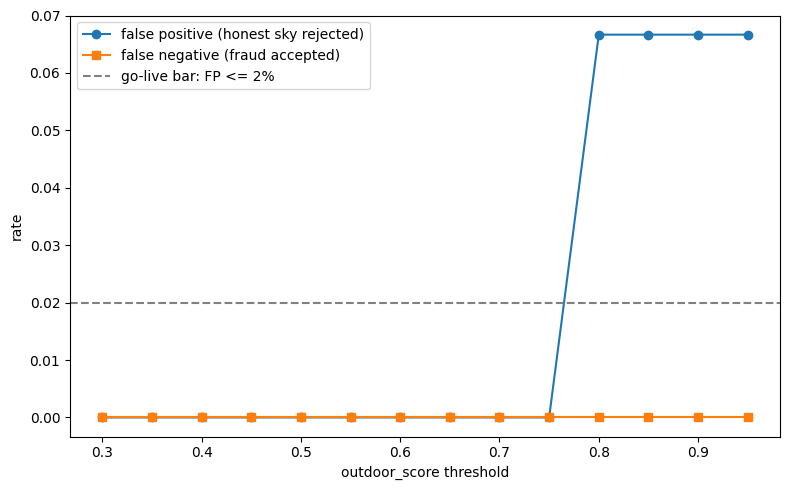

0.30  FP 0.0%  FN 0.0%
0.35  FP 0.0%  FN 0.0%
0.40  FP 0.0%  FN 0.0%
0.45  FP 0.0%  FN 0.0%
0.50  FP 0.0%  FN 0.0%
0.55  FP 0.0%  FN 0.0%
0.60  FP 0.0%  FN 0.0%
0.65  FP 0.0%  FN 0.0%
0.70  FP 0.0%  FN 0.0%
0.75  FP 0.0%  FN 0.0%
0.80  FP 6.7%  FN 0.0%
0.85  FP 6.7%  FN 0.0%
0.90  FP 6.7%  FN 0.0%
0.95  FP 6.7%  FN 0.0%


In [7]:
import csv

golden = Path("data/golden")
rows = list(csv.DictReader((golden / "manifest.csv").open()))
scored = [(model.analyze((golden / "images" / r["filename"]).read_bytes())[0], r["label"])
          for r in rows]

thresholds = [i / 100 for i in range(30, 96, 5)]
fp_rates, fn_rates = [], []
for t in thresholds:
    skies = [s for s, l in scored if l == "sky"]
    frauds = [s for s, l in scored if l == "fraud"]
    fp_rates.append(sum(1 for s in skies if s < t) / len(skies))
    fn_rates.append(sum(1 for s in frauds if s >= t) / len(frauds))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, fp_rates, marker="o", label="false positive (honest sky rejected)")
ax.plot(thresholds, fn_rates, marker="s", label="false negative (fraud accepted)")
ax.axhline(0.02, linestyle="--", color="grey", label="go-live bar: FP <= 2%")
ax.set_xlabel("outdoor_score threshold")
ax.set_ylabel("rate")
ax.legend()
plt.tight_layout()
plt.savefig("training/threshold_curve.png", dpi=120)
plt.show()

for t, fp, fn in zip(thresholds, fp_rates, fn_rates):
    print(f"{t:.2f}  FP {fp:.1%}  FN {fn:.1%}")

## Conclusion

- **Held-out accuracy (CLEAR/CLOUDY/RAIN only, section 2)**: the probe beats zero-shot on every measurable group -- see the printed numbers above. This is the only comparison in this notebook measured on images genuinely absent from both training and tuning.
- **FOG/SNOW/STORM (section 4)**: not covered by the held-out set at all -- neither Kaggle source offers an independent sample of these three groups. The 5-fold cross-validated, out-of-fold numbers in section 4 are the only honest per-class signal available for them, computed on the training pool at zero cost to the data the shipped probe trains on.
- **FOG/SNOW misclassification rate (section 2)**: the rate at which an honest CLEAR/CLOUDY/RAIN capture would be scored into FOG or SNOW -- the exact case the backend's contradiction matrix (only FOG admits FOG, only SNOW admits SNOW) would reject as a phenomenon mismatch. Read this number, not just the headline accuracy, before deciding this is safe to ship against that matrix.
- `OUTDOOR_THRESHOLD` in `tests/test_accuracy.py` is a product decision (0.60) and is not changed by this notebook -- the threshold curve above is informational only, reproduced from the existing golden set for reference alongside the probe numbers.